# Bölüm 3 — Uygulama: Risk Segmentasyonu ve Belirsiz Kayıtların Sınıflandırılması

**Proje:** GPT Eklenti Ekosisteminde Gizlilik Riski Analizi ve Otomatik Sınıflandırma

**Araştırma Sorusu 4:** Eklentileri topladıkları veri türüne göre gruplandırdığımızda doğal riskli/risksiz kümeler ortaya çıkıyor mu? (kümeleme)

**Araştırma Sorusu 5:** Bölüm 2'de kurduğumuz model, etiketi belirsiz olan kayıtları (özellikle `data_type`'ta "Other" kategorisi, 3.544 kayıt) sınıflandırmak için kullanılabilir mi?

**Bu bölümün planı:**
1. Problemi kurma: parametre-seviyesinden eklenti-seviyesine geçiş — her eklentinin "veri toplama profilini" çıkarma
2. Kümeleme: eklentileri veri toplama profiline göre gruplama, kümeleri yorumlama (riskli/risksiz ayrımı var mı?)
3. Bölüm 2 modelini "Other" kayıtlarına uygulama, sonuçları temkinli yorumlama
4. Genel proje özeti

## Adım 1 — Parametre Seviyesinden Eklenti Seviyesine Geçiş

Bölüm 1 ve 2'de her satır bir **parametreydi**. Ama Araştırma Sorusu 4 eklentileri (GPT Actions) gruplamak istiyor — yani analiz birimimizi değiştirmemiz lazım: parametreden **eklentiye**.

**Zorluk:** `plugin_id_filenames` bir liste — aynı parametre birden fazla eklenti tarafından kullanılabiliyor (örn. yaygın bir "user_id" parametresi yüzlerce eklentide geçebilir). Bunu çözmek için veriyi "patlatacağız" (explode): her (eklenti, parametre) çifti kendi satırı olacak. Böylece "bu eklenti hangi parametreleri/kategorileri topluyor" sorusuna cevap verebileceğiz.

**Eklenti profili nasıl çıkarılır:** Her eklenti için, topladığı parametrelerin **kategori bazında oranını** hesaplayacağız (örn. "bu eklentinin parametrelerinin %30'u Identifier, %10'u Security credentials..."). Oran kullanıyoruz, ham sayı değil — çünkü eklentiler büyüklük olarak çok farklı (1 parametreden 1000+ parametreye kadar); önemli olan eklentinin büyüklüğü değil, *neyi topladığının profili*.

**Minimum parametre eşiği:** Sadece 1-2 parametresi olan bir eklentinin "profili" anlamsız olur (tek kategoriye %100 ait görünür, bu bir örüntü değil şans eseri). Bu yüzden en az **3 parametreli** eklentileri alacağız — bu bize 4.592 eklentiden **3.041**'ini bırakıyor, yeterince büyük bir örneklem.

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

DATA_PATH = '../backend/data/data_entries_final.json'

with open(DATA_PATH, 'r', encoding='utf-8') as f:
    raw_data = json.load(f)

df = pd.DataFrame(raw_data)
df['text'] = (df['name'].fillna('') + '. ' + df['description'].fillna('')).str.strip()

df_exploded = df.explode('plugin_id_filenames').rename(columns={'plugin_id_filenames': 'plugin_id'}).reset_index(drop=True)

print('Parametre kaydı sayısı:', len(df))
print('Patlatma sonrası (eklenti, parametre) satır sayısı:', len(df_exploded))
print('Benzersiz eklenti sayısı:', df_exploded['plugin_id'].nunique())

Parametre kaydı sayısı: 12811
Patlatma sonrası (eklenti, parametre) satır sayısı: 40261
Benzersiz eklenti sayısı: 4592


In [2]:
MIN_PARAMS = 3

plugin_param_counts = df_exploded.groupby('plugin_id').size()
eligible_plugins = plugin_param_counts[plugin_param_counts >= MIN_PARAMS].index

df_exploded_filtered = df_exploded[df_exploded['plugin_id'].isin(eligible_plugins)]

plugin_category_counts = pd.crosstab(df_exploded_filtered['plugin_id'], df_exploded_filtered['main_data_type'])
plugin_profile = plugin_category_counts.div(plugin_category_counts.sum(axis=1), axis=0)

print(f'{MIN_PARAMS}+ parametreli eklenti sayısı: {len(plugin_profile)}')
print('Profil matrisi boyutu:', plugin_profile.shape)
plugin_profile.head(3)

3+ parametreli eklenti sayısı: 3041
Profil matrisi boyutu: (3041, 25)


main_data_type,App metadata,App usage data,E-commerce data,Event information,Files and documents,Finance information,Food and nutrition information,Gaming data,Health information,Identifier,Legal and law enforcement data,Location,Market data,Message,Other,Personal information,Query,Real estate data,Security credentials,Sports information,Time,Travel information,Vehicle information,Weather information,Web and network data
plugin_id,,,,,,,,,,,,,,,,,,,,,,,,,
g-009xFjOLC_OoDqO0qGP1tw2zGRYCYIfpUK,0.25,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.25,0.0,0.0,0.0,0.0,0.0,0.25,0.0,0.0,0.25,0.0,0.0,0.0,0.0,0.0,0.0
g-00y8F1eRb_APoRCDy5ffgP0bHoQMuTHeML,0.00,0.7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.2,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.1
g-02IWjW9i4_gzm_cnf_brjSH6N13PZzuSsTMwtje1dt~gzm_tool_u3iT5JbQPY0dX8WI6dUjMMYB,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,1.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0


## Adım 2 — Kümeleme: Kaç Doğal Grup Var?

**Sezgi:** K-Means, elimizdeki 3.041 eklentiyi, veri toplama profili (25 kategorideki oranlar) birbirine benzeyen eklentileri aynı gruba koyarak kümelere ayırıyor — hiçbir etiket vermeden, sadece "hangi eklentiler birbirine benziyor" sorusuna bakarak. Amacımız: bu kümelerden biri doğal olarak "hassas veri ağırlıklı" (riskli), bir diğeri "zararsız/genel amaçlı" (risksiz) çıkıyor mu görmek.

**Standartlaştırma:** Kategoriler arasında varyans çok farklı (örn. "Other" oranı eklentiden eklentiye çok değişirken "Health information" oranı çoğu eklentide sıfıra yakın kalıyor). Standartlaştırma yapmazsak, kümeleme sadece en çok değişen 1-2 kategoriye göre şekillenir. Bu yüzden her kategoriyi (ortalama 0, standart sapma 1 olacak şekilde) standartlaştırıyoruz — böylece 25 kategori de kümelenmede eşit söz sahibi oluyor.

**Kaç küme (K) seçmeli:** Bunu veriden görmeden tahmin etmiyoruz — birkaç farklı K değeri deneyip **silhouette skoru**na bakacağız. Bu skor, her eklentinin kendi kümesine ne kadar "ait" hissettiğini, başka kümelere göre ne kadar "uzak" olduğunu ölçüyor; yüksek skor daha net ayrışmış kümeler demek.

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scaler = StandardScaler()
profile_scaled = scaler.fit_transform(plugin_profile)

k_range = range(2, 11)
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(profile_scaled)
    score = silhouette_score(profile_scaled, labels)
    silhouette_scores.append(score)
    print(f'K={k}: silhouette skoru = {score:.3f}')

K=2: silhouette skoru = 0.215


K=3: silhouette skoru = 0.211


K=4: silhouette skoru = 0.219


K=5: silhouette skoru = 0.216
K=6: silhouette skoru = 0.226


K=7: silhouette skoru = 0.227
K=8: silhouette skoru = 0.170


K=9: silhouette skoru = 0.237
K=10: silhouette skoru = 0.254


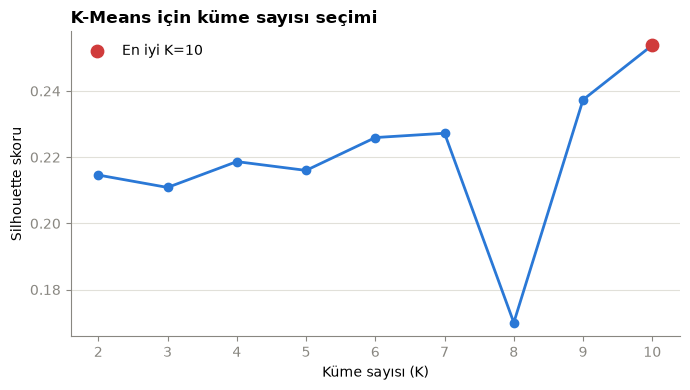

Seçilen K: 10 (silhouette skoru: 0.254)


In [4]:
COLOR_MAIN = '#2a78d6'
COLOR_MUTED = '#898781'
COLOR_TEXT = '#0b0b0b'

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(k_range), silhouette_scores, marker='o', color=COLOR_MAIN, linewidth=2, markersize=6)

best_k = list(k_range)[int(np.argmax(silhouette_scores))]
best_score = max(silhouette_scores)
ax.scatter([best_k], [best_score], color='#d03b3b', zorder=5, s=80, label=f'En iyi K={best_k}')

ax.set_xlabel('Küme sayısı (K)')
ax.set_ylabel('Silhouette skoru')
ax.set_title('K-Means için küme sayısı seçimi', loc='left', fontsize=12, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color(COLOR_MUTED)
ax.tick_params(colors=COLOR_MUTED)
ax.grid(axis='y', color='#e1e0d9', linewidth=0.8)
ax.set_axisbelow(True)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

print(f'Seçilen K: {best_k} (silhouette skoru: {best_score:.3f})')

In [5]:
final_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
plugin_profile['cluster'] = final_kmeans.fit_predict(profile_scaled)

print(f'{best_k} kümeye göre eklenti dağılımı:')
print(plugin_profile['cluster'].value_counts().sort_index())

10 kümeye göre eklenti dağılımı:
cluster
0    1523
1      83
2     338
3     154
4      14
5       3
6       5
7      11
8     891
9      19
Name: count, dtype: int64


### Bulgu (K seçimi)

İki şeyi not etmek gerekiyor:

1. **Silhouette skorları genel olarak düşük** (0.17–0.25 arasında) — bu, eklentilerin veri toplama profillerine göre **net, birbirinden kesin çizgilerle ayrılmış** kümeler oluşturmadığını gösteriyor. Beklenen bir sonuç aslında: gerçek dünya verisi nadiren mükemmel kümelere ayrılır, çoğu eklenti muhtemelen birkaç kategoriyi karışık şekilde kullanıyor.
2. K arttıkça skor genel olarak yükseliyor ve en yüksek skor K=10'da çıkıyor, ama **küme büyüklükleri çok dengesiz**: iki büyük küme (1523 ve 891 eklenti) çoğunluğu kaplıyor, geri kalan 8 küme çok daha küçük (bazıları sadece 3-19 eklenti). Bu küçük kümeler gürültü olabilir, ama aynı zamanda **çok spesifik, tek bir kategoriye yoğunlaşmış eklenti grupları** da olabilir — bunu bir sonraki adımda küme profillerine bakarak anlayacağız.

Şimdilik K=10'u veriden gelen seçim olarak kabul edip devam ediyoruz; küçük kümelerin anlamlı mı yoksa gürültü mü olduğuna profil analiziyle karar vereceğiz.

## Adım 3 — Kümeleri Yorumlama: Riskli/Risksiz Ayrımı Var mı?

Her kümenin "ortalama profilini" (centroid) hesaplayıp iki şeye bakacağız:
1. **O kümedeki eklentiler en çok hangi kategorilerden veri topluyor?** (en baskın 3 kategori)
2. **O kümenin 4 hassas kategorideki (Security credentials, Personal information, Health information, Finance information) toplam payı ne kadar?** — buna "hassas pay" diyeceğiz ve kümeleri buna göre sıralayacağız.

Eğer Araştırma Sorusu 4'ün cevabı "evet" ise, hassas payı yüksek bir veya birkaç küme, düşük olanlardan net şekilde ayrılmalı.

In [6]:
SENSITIVE_CATEGORIES = ['Security credentials', 'Personal information', 'Health information', 'Finance information']

centroids = plugin_profile.groupby('cluster').mean()
cluster_sizes = plugin_profile['cluster'].value_counts().sort_index()
sensitive_share = centroids[SENSITIVE_CATEGORIES].sum(axis=1)

cluster_summary = pd.DataFrame({
    'eklenti_sayısı': cluster_sizes,
    'hassas_pay': sensitive_share,
})
cluster_summary['baskın_kategoriler'] = [
    ', '.join(f'{cat} (%{val*100:.0f})' for cat, val in centroids.loc[c].sort_values(ascending=False).head(3).items())
    for c in cluster_summary.index
]
cluster_summary = cluster_summary.sort_values('hassas_pay', ascending=False)
cluster_summary['hassas_pay'] = (cluster_summary['hassas_pay'] * 100).round(1)
cluster_summary

,eklenti_sayısı,hassas_pay,baskın_kategoriler
cluster,,,
1,83,16.1,"Market data (%41), Time (%19), Finance informa..."
8,891,12.5,"Identifier (%22), Other (%18), App usage data ..."
5,3,10.5,"Real estate data (%45), Location (%16), App us..."
2,338,9.4,"Message (%21), Files and documents (%20), App ..."
6,5,4.2,"Food and nutrition information (%51), Query (%..."
4,14,3.4,"E-commerce data (%56), Identifier (%12), Web a..."
7,11,2.3,"Travel information (%42), Time (%21), Identifi..."
9,19,2.2,"Location (%37), Weather information (%27), App..."
0,1523,1.5,"App usage data (%49), Query (%22), Web and net..."


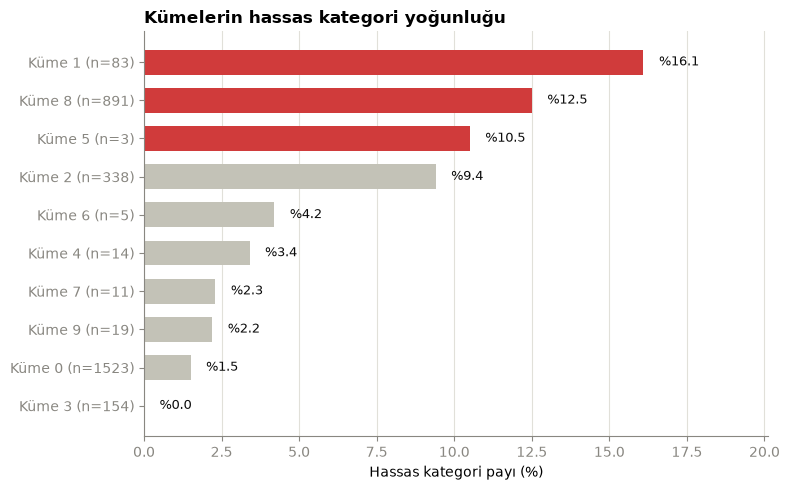

In [7]:
COLOR_SENSITIVE = '#d03b3b'
COLOR_NEUTRAL = '#c3c2b7'
COLOR_TEXT = '#0b0b0b'
COLOR_MUTED = '#898781'

ordered = cluster_summary.sort_values('hassas_pay')
colors = [COLOR_SENSITIVE if v >= 10 else COLOR_NEUTRAL for v in ordered['hassas_pay']]
labels = [f'Küme {c} (n={n})' for c, n in zip(ordered.index, ordered['eklenti_sayısı'])]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(labels, ordered['hassas_pay'], color=colors, height=0.65)

for bar, val in zip(bars, ordered['hassas_pay']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, f'%{val:.1f}',
            va='center', ha='left', fontsize=9, color=COLOR_TEXT)

ax.set_xlabel('Hassas kategori payı (%)')
ax.set_title('Kümelerin hassas kategori yoğunluğu', loc='left', fontsize=12, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color(COLOR_MUTED)
ax.tick_params(colors=COLOR_MUTED)
ax.grid(axis='x', color='#e1e0d9', linewidth=0.8)
ax.set_axisbelow(True)
ax.set_xlim(0, ordered['hassas_pay'].max() * 1.25)

plt.tight_layout()
plt.show()

### Bulgu (Araştırma Sorusu 4)

Cevap net bir "evet" değil, ama tamamen "hayır" da değil — **daha nüanslı bir tablo çıkıyor:**

- Kümeleme, hassas/hassas-değil ekseninde temiz bir ikili ayrım üretmek yerine, **fonksiyonel/tematik gruplar** ortaya çıkarıyor: pazar & finans verisi (Küme 1), gündelik uygulama kullanımı (Küme 0 — en büyük küme, 1523 eklenti), kimlik/genel amaçlı (Küme 8 — ikinci en büyük, 891 eklenti), mesajlaşma & dosya (Küme 2), seyahat (Küme 7), e-ticaret (Küme 4), konum & hava durumu (Küme 9), emlak (Küme 5), gıda (Küme 6), ve sadece uygulama meta verisi toplayan bir küme (Küme 3).
- Hassas kategori payı bu kümeler arasında **derece derece dağılıyor**, keskin bir sıçrama yok: en yüksek %16.1 (Küme 1, pazar/finans ağırlıklı ama sadece 83 eklenti), en düşük %0 (Küme 3, sadece "App metadata" ve "Query" topluyor, 154 eklenti).
- Önemli bir gözlem: **en büyük iki küme** (Küme 0 ve Küme 8, birlikte eklentilerin ~%80'i) düşük-orta hassas paya sahip (%1.5 ve %12.5). Yani genel eklenti popülasyonunun büyük çoğunluğu zaten nispeten düşük riskli görünüyor; yüksek hassas pay, küçük ve spesifik-amaçlı kümelerde (finans, emlak gibi) yoğunlaşıyor.

**Sonuç:** Doğal kümeler "riskli vs risksiz" diye ikiye ayrılmıyor, ama kümelerin hassas veri yoğunluğuna göre **sıralanabilmesi** kendi başına faydalı bir risk segmentasyonu aracı — örn. Küme 1 ve Küme 8'deki eklentiler, incelemeye öncelik verilmesi gereken gruplar olarak işaretlenebilir.

## Adım 4 — Modeli "Other" Kayıtlarına Uygulama (Araştırma Sorusu 5)

**Kritik bir metodoloji kararı:** Bölüm 2'deki `data_type` modelini olduğu gibi kullanamayız, çünkü o model "Other"ı da eğitim sırasında **geçerli bir sınıf** olarak görmüştü. Burada amacımız farklı: "Other" etiketi zaten güvenilir değil (belirsiz/etiketlenmemiş anlamına geliyor), bu yüzden modele "Other diye bir sınıf var" bile dememeliyiz — aksi halde model büyük ihtimalle her şeyi yine "Other" olarak tahmin eder ve hiçbir şey öğrenmemiş oluruz.

**Çözüm:** Modeli **sadece "Other" olmayan** 9.267 kayıtla, gerçek 144 `data_type` değeri üzerinden (yine nadir sınıfları gruplayarak, 77 kullanılabilir sınıf + 1 nadir kova = 78 sınıf) yeniden eğiteceğiz. Böylece model "Other" kayıtlarına baktığında, gerçek 78 kategoriden **en olası olanını** önermek zorunda kalacak — "bilmiyorum" diyip Other'a kaçamayacak.

**Güven skoru:** Model her tahmin için bir olasılık dağılımı üretir. En yüksek olasılığı **"güven skoru"** olarak kullanacağız — düşük güvenli tahminlere (örn. model %15 ihtimalle A, %14 ihtimalle B diyorsa) çok temkinli yaklaşmalıyız; bunlar gerçek bir öneriden çok "zar attım" durumuna yakın.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

RARE_THRESHOLD = 10

df_known = df[df['data_type'] != 'Other'].copy()
df_other = df[df['data_type'] == 'Other'].copy()

known_type_counts = df_known['data_type'].value_counts()
rare_types = known_type_counts[known_type_counts < RARE_THRESHOLD].index
df_known['data_type_grouped'] = df_known['data_type'].where(~df_known['data_type'].isin(rare_types), 'Nadir tür (birleştirilmiş)')

print('Other olmayan kayıt sayısı:', len(df_known))
print('Other kayıt sayısı:', len(df_other))
print('Sınıf sayısı (gruplama sonrası):', df_known['data_type_grouped'].nunique())

X_known = df_known['text']
y_known = df_known['data_type_grouped']

X_train_k, X_test_k, y_train_k, y_test_k = train_test_split(
    X_known, y_known, test_size=0.2, random_state=42, stratify=y_known
)

tfidf_other = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words='english')
X_train_k_tfidf = tfidf_other.fit_transform(X_train_k)
X_test_k_tfidf = tfidf_other.transform(X_test_k)

model_other = LogisticRegression(max_iter=1000, random_state=42)
model_other.fit(X_train_k_tfidf, y_train_k)

y_pred_k = model_other.predict(X_test_k_tfidf)
print()
print(f'Kendi test setinde accuracy: {accuracy_score(y_test_k, y_pred_k):.3f}')
print(f'Kendi test setinde macro F1: {f1_score(y_test_k, y_pred_k, average="macro"):.3f}')

Other olmayan kayıt sayısı: 9267
Other kayıt sayısı: 3544
Sınıf sayısı (gruplama sonrası): 78



Kendi test setinde accuracy: 0.690
Kendi test setinde macro F1: 0.429


In [9]:
# Modeli, hiç görmediği tüm "Other" kayıtlarına uyguluyoruz.
X_other_tfidf = tfidf_other.transform(df_other['text'])

other_pred_proba = model_other.predict_proba(X_other_tfidf)
other_predictions = model_other.classes_[np.argmax(other_pred_proba, axis=1)]
other_confidence = other_pred_proba.max(axis=1)

df_other['predicted_data_type'] = other_predictions
df_other['confidence'] = other_confidence

print('Güven skoru dağılımı:')
print(df_other['confidence'].describe().round(3))

Güven skoru dağılımı:
count    3544.000
mean        0.289
std         0.172
min         0.081
25%         0.198
50%         0.209
75%         0.341
max         0.993
Name: confidence, dtype: float64


**İlk gözlem:** Kendi test setinde model makul bir performans gösteriyor (accuracy %69, Bölüm 2'deki `data_type` modeline çok yakın — beklendiği gibi, çünkü aynı yöntem). Ama "Other" kayıtlarına uygulayınca güven skorları genel olarak **düşük**: medyan sadece %20.9. Bu şaşırtıcı değil — "Other" etiketi zaten muhtemelen gerçekten belirsiz/genel kayıtları içeriyor, model de bunu "kararsızlık" olarak yansıtıyor. Yine de bazı kayıtlarda güven %99'a kadar çıkıyor — demek ki bazı "Other" kayıtları aslında net bir kategoriye ait ama yanlış etiketlenmiş olabilir.

Şimdi güven skorlarının dağılımına ve yüksek güvenli tahminlerin neler önerdiğine bakalım.

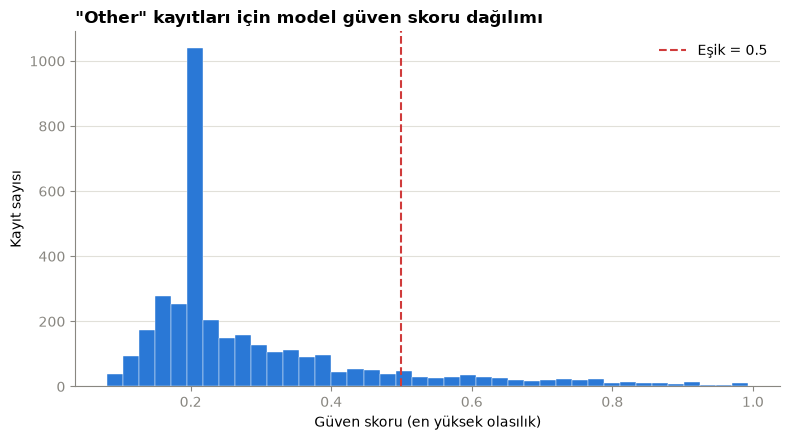

Güven skoru >= 0.5 olan kayıt sayısı: 411 (11.6%)


In [10]:
COLOR_MAIN = '#2a78d6'
COLOR_CONFIDENT = '#1baf7a'
COLOR_MUTED = '#898781'
COLOR_TEXT = '#0b0b0b'
CONFIDENCE_THRESHOLD = 0.5

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(df_other['confidence'], bins=40, color=COLOR_MAIN, edgecolor='white', linewidth=0.3)
ax.axvline(CONFIDENCE_THRESHOLD, color='#d03b3b', linewidth=1.5, linestyle='--',
           label=f'Eşik = {CONFIDENCE_THRESHOLD}')

ax.set_xlabel('Güven skoru (en yüksek olasılık)')
ax.set_ylabel('Kayıt sayısı')
ax.set_title('"Other" kayıtları için model güven skoru dağılımı', loc='left', fontsize=12, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color(COLOR_MUTED)
ax.tick_params(colors=COLOR_MUTED)
ax.grid(axis='y', color='#e1e0d9', linewidth=0.8)
ax.set_axisbelow(True)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

n_confident = (df_other['confidence'] >= CONFIDENCE_THRESHOLD).sum()
print(f'Güven skoru >= {CONFIDENCE_THRESHOLD} olan kayıt sayısı: {n_confident} ({n_confident/len(df_other)*100:.1f}%)')

In [11]:
confident_other = df_other[df_other['confidence'] >= CONFIDENCE_THRESHOLD]

print(f'Güvenli tahminlerin (n={len(confident_other)}) önerdiği ilk 15 kategori:')
print(confident_other['predicted_data_type'].value_counts().head(15))

Güvenli tahminlerin (n=411) önerdiği ilk 15 kategori:
predicted_data_type
Current session setting    218
Resource IDs                80
Search query                39
Query filter                35
User identifiers             6
URLs                         5
Ticker symbol                4
Date                         4
Email address                3
API key                      3
Text messages                2
State/province               2
Time period                  2
Multimedia data              2
Database information         2
Name: count, dtype: int64


**Gizlilik açısından en kritik soru:** Bu güvenli tahminlerden kaçı bir **hassas kategoriye** (`main_data_type` düzeyinde) işaret ediyor? Yani, "Other" diye etiketlenmiş ama aslında hassas bir veri türü olabilecek kayıtlar var mı? Bunu kontrol etmek için her `data_type` değerinin hangi `main_data_type`'a ait olduğunu eşleyeceğiz (neredeyse her `data_type` tek bir `main_data_type`'a karşılık geliyor).

In [12]:
SENSITIVE_CATEGORIES = ['Security credentials', 'Personal information', 'Health information', 'Finance information']

data_type_to_main = df_known.groupby('data_type')['main_data_type'].agg(lambda s: s.mode()[0])

confident_other = confident_other.copy()
confident_other['predicted_main_type'] = confident_other['predicted_data_type'].map(data_type_to_main)
confident_other['predicted_is_sensitive'] = confident_other['predicted_main_type'].isin(SENSITIVE_CATEGORIES)

n_sensitive_flagged = confident_other['predicted_is_sensitive'].sum()
print(f'Güvenli tahmin edilen {len(confident_other)} "Other" kaydından '
      f'{n_sensitive_flagged} tanesi hassas bir kategoriye işaret ediyor.')
print()
print('Bu kayıtların önerilen main_data_type dağılımı:')
print(confident_other.loc[confident_other['predicted_is_sensitive'], 'predicted_main_type'].value_counts())

Güvenli tahmin edilen 411 "Other" kaydından 7 tanesi hassas bir kategoriye işaret ediyor.

Bu kayıtların önerilen main_data_type dağılımı:
predicted_main_type
Security credentials    4
Personal information    3
Name: count, dtype: int64


In [13]:
sensitive_examples = confident_other[confident_other['predicted_is_sensitive']].sort_values('confidence', ascending=False)
sensitive_examples[['name', 'description', 'predicted_data_type', 'predicted_main_type', 'confidence']].head(10)

,name,description,predicted_data_type,predicted_main_type,confidence
874,email,,Email address,Personal information,0.909600
12055,email,Email of the vendor.,Email address,Personal information,0.898941
1721,key,,API key,Security credentials,0.822185
3086,skills,过滤 skill key,API key,Security credentials,0.822185
10025,KEY,,API key,Security credentials,0.822185
4287,token,Identifier of the token,Access tokens,Security credentials,0.506541
3971,email_type,The email type.,Email address,Personal information,0.503544


### Bulgu (Araştırma Sorusu 5)

**Cevap: kısmen evet, ama sadece küçük ve dikkatli seçilmiş bir alt küme için.**

- 3.544 "Other" kaydının sadece **%11.6'sı (411 kayıt)** güven eşiğini (%50) geçiyor. Geri kalan büyük çoğunluk için model de kararsız — bu kayıtlar muhtemelen gerçekten belirsiz/genel amaçlı, "Other" etiketi haksız değil.
- Güvenli tahminlerin çoğu zaten sezgisel kategoriler: `Current session setting`, `Resource IDs`, `Search query` gibi genel-amaçlı teknik alanlar.
- Ama **7 kayıt**, güvenli şekilde bir **hassas kategoriye** (`Security credentials` veya `Personal information`) işaret ediyor. Örneklere bakınca bu hiç şaşırtıcı değil: `name="email"`, `name="key"`, `name="KEY"`, `name="token"` gibi kayıtlar %82-91 güvenle "Email address" / "API key" / "Access tokens" olarak öneriliyor — orijinal veri setinde bunlar "Other" olarak etiketlenmiş, ama isimlerinden bile bariz ki hassas veri.

**Genel sonuç:** Model, "Other" etiketli kayıtların **tamamını** güvenilir şekilde yeniden sınıflandıramaz — ama küçük bir alt kümede (**yüksek güvenli tahminler**) gerçekten yanlış etiketlenmiş, hassas veri türlerini yakalayabiliyor. Pratik bir öneri olarak: bu modeli "otomatik yeniden etiketleme" için değil, **"gözden geçirme için öncelik listesi çıkarma"** amacıyla kullanmak daha doğru olur — yüksek güvenli ve hassas kategoriye işaret eden birkaç yüz kayıt, insan gözden geçirmesi için makul bir öncelik listesi oluşturuyor.

## Özet — Bölüm 3

**Araştırma Sorusu 4 cevabı:** Eklentileri veri toplama profiline göre kümelediğimizde net bir "riskli vs risksiz" ikili ayrım çıkmıyor. Bunun yerine **fonksiyonel/tematik kümeler** ortaya çıkıyor (finans & pazar, seyahat, e-ticaret, konum & hava durumu, mesajlaşma & dosya, genel amaçlı, sadece meta veri toplayan) ve hassas kategori yoğunluğu bu kümeler arasında **kademeli olarak** (%0 ile %16.1 arasında) dağılıyor. Eklentilerin büyük çoğunluğu (~%80) zaten düşük-orta hassas paya sahip; yüksek risk küçük, spesifik-amaçlı kümelerde yoğunlaşıyor. Pratik çıkarım: kümeler ikili bir etiket değil, **sıralanabilir bir risk skoru** sağlıyor.

**Araştırma Sorusu 5 cevabı:** Bölüm 2 modelini "Other" olmadan yeniden eğitip 3.544 "Other" kaydına uyguladık. Sonuç **kısmen olumlu**: kayıtların sadece %11.6'sı yüksek güvenle (≥%50) yeniden sınıflandırılabiliyor — çoğu gerçekten belirsiz kalıyor. Ama bu küçük güvenli alt kümede, `name="email"`, `name="key"`, `name="token"` gibi **açıkça hassas** kayıtlar doğru şekilde yakalanıyor. Model, otomatik yeniden etiketleme için değil, **insan gözden geçirmesi için öncelik listesi** çıkarmak için kullanılabilir.

## Genel Proje Özeti

**Proje:** GPT Eklenti Ekosisteminde Gizlilik Riski Analizi ve Otomatik Sınıflandırma — 12.811 parametre kaydı, 4.592 eklenti, 25 kaba / 145 ince veri kategorisi.

| # | Araştırma Sorusu | Cevap |
|---|---|---|
| 1 | Kategori dağılımı, hassas pay? | Dağılım çarpık (top-3 kategori %48.2); 4 hassas kategori toplamın **%7.3**'ü |
| 2 | Açıklama yazma oranı hassas/hassas-değil farklı mı? | İstatistiksel olarak anlamlı (p≈0.006) ama etki büyüklüğü ihmal edilebilir (Cramér's V≈0.024) — pratikte fark yok |
| 3 | Ad+açıklamadan kategori tahmin edilebilir mi? | Evet, orta düzeyde: TF-IDF+LogReg **%68.9 accuracy, %46.8 macro F1**; embedding genelde geride ama nadir sınıflarda üstün; model sistematik olarak "Other"a kaçıyor |
| 4 | Eklentiler doğal riskli/risksiz kümelere ayrılıyor mu? | Hayır, net ikili ayrım yok — fonksiyonel kümeler çıkıyor, hassas pay kademeli dağılıyor (%0–%16.1) |
| 5 | Model "Other" kayıtlarını sınıflandırabilir mi? | Kısmen — kayıtların sadece %11.6'sı güvenle yeniden etiketlenebiliyor, ama bu alt küme gerçek hassas-veri yanlış etiketlemelerini (email, key, token) yakalıyor |

**Ortak tema:** Proje boyunca tekrar eden en güçlü sinyal, **"Other" kategorisinin bir çöp kutusu gibi davranması** — hem Bölüm 2'nin classification report'unda, hem confusion matrix'inde, hem de Bölüm 3'ün "Other" sınıflandırma denemesinde aynı örüntü çıktı. Bu, hem veri kalitesi (etiketleme tutarsızlığı) hem de model güvenilirliği açısından projenin en önemli bulgusu.

**Metodolojik not:** Bu ortamda Hugging Face'e ağ erişimi organizasyon politikası gereği engellendiği için embedding modelinde `sentence-transformers` yerine spaCy'nin GloVe tarzı kelime vektörleri kullanıldı — sonuçlar buna göre yorumlanmalı.

**Sınırlamalar ve gelecek çalışma:** (1) `data_type` üzerindeki modelleme nadir sınıfları gruplamak zorunda kaldı, bu bilgi kaybı yaratıyor; (2) kümeleme sonuçları düşük silhouette skorları nedeniyle kesin değil; (3) "Other" kayıtlarına uygulanan model gerçek etiketle doğrulanamadı (ground truth yok), bulgular nitel örneklerle desteklendi ama sistematik bir doğrulama yapılmadı — gerçek bir uygulamada bu tahminler mutlaka insan gözden geçirmesinden geçmeli.